In [41]:
import pytato as yt
import pandas as pd

In [42]:
proteome_df = yt.Silico().import_fasta(source="https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/reference_proteomes/Eukaryota/UP000005640/UP000005640_9606.fasta.gz")

FASTA import complete!


In [43]:
results = []
silico = yt.Silico()  

for index, row in proteome_df.head(5).iterrows():
    peptides = silico.cleave_sequence(sequence=row['Peptide'], enzyme="trypsin")
    for peptide in peptides:
        results.append({
            'Gene': row['Gene'],
            'Peptide': peptide
        })

peptides_df = pd.DataFrame(results)


In [44]:
peptides_df

,Gene,Peptide
0,A0A0A0MT85,XCSFGQGTK
1,HV692,MDCTWR
2,HV692,ILLLVAAATGTHAEVQLVQSGAEVK
3,HV692,KPGATVK
4,HV692,VSGYTFTDYYMHWVQQAPGK
5,HV692,GLEWMGLVDPEDGETIYAEK
6,HV692,VTITADTSTDTAYMELSSLR
7,HV692,SEDTAVYYCAT
8,SCGR4,MGCCGCGSCGGCGGR
9,SCGR4,CGGGCGGGCSGGCGGGCGGGCGGGCGSCTTCR


In [45]:
peptide_counts = peptides_df.groupby('Gene').size()
print(peptide_counts)


Gene
A0A0A0MT85     1
A0A6Q8PGS0     7
DHR12         21
HV692          7
SCGR4          6
dtype: int64


In [46]:

specific_proteins = proteome_df[proteome_df['Gene'].isin(['PDK1',"UBE3B"])]


In [47]:
silico.missed = 1


In [48]:
peptide_properties_dic = silico.generate_samples(proteome_df,enzyme="trypsin", target="Peptide", identifier="Gene", pH=7.4, min_charge=1.5)
peptides_df = pd.DataFrame(peptide_properties_dic)


Processing your order with trypsin-cut proteins.
Generated 197040 peptides matching criteria.


In [49]:
peptides_df

,gene,peptide,Length,aa_comp,z,Mass,GRAVY,m/z
0,HV692,KPGATVK,7,"{'G': 1, 'A': 1, 'V': 1, 'P': 1, 'K': 2, 'T': 1}",2,681.417361,-0.642857,340.708681
1,HV692,KPGATVKISCK,11,"{'S': 1, 'G': 1, 'A': 1, 'I': 1, 'C': 1, 'V': ...",3,1112.637601,-0.200000,370.879200
2,SCGR4,MGCCGCGSCGGCGGRCGGGCGGGCSGGCGGGCGGGCGGGCGSCTTCR,47,"{'S': 3, 'G': 25, 'C': 14, 'R': 2, 'M': 1, 'T'...",2,3774.099339,0.300000,1887.049669
3,SCGR4,CGGGCGGGCSGGCGGGCGGGCGGGCGSCTTCRCYR,35,"{'S': 2, 'G': 18, 'C': 10, 'R': 2, 'Y': 1, 'T'...",2,2907.903158,0.128571,1453.951579
4,SCGR4,CYRVGCCSSCCPCCR,15,"{'S': 2, 'G': 1, 'C': 7, 'V': 1, 'P': 1, 'R': ...",2,1623.536535,0.520000,811.768267
...,...,...,...,...,...,...,...,...
197035,ZHX2,MFNGTIQSVPPTITVLPAQLAPTKVTQPILQTALPCQILGQTSLVL...,74,"{'S': 6, 'G': 5, 'A': 5, 'I': 5, 'Q': 8, 'C': ...",2,7555.917082,0.433784,3777.958541
197036,ZHX2,VTQPILQTALPCQILGQTSLVLTQVTSGSTTVSCSPITLAVAGVTN...,63,"{'S': 5, 'G': 4, 'A': 5, 'E': 1, 'Q': 7, 'I': ...",2,6433.365217,0.201587,3216.682609
197037,ZHX2,RPLVTPQAAPEPKRPHIAQVPEPPPK,26,"{'A': 3, 'E': 2, 'Q': 2, 'I': 1, 'H': 1, 'V': ...",2,2831.592255,-1.038462,1415.796128
197038,ZHX2,CLLKTGTVK,9,"{'G': 1, 'C': 1, 'V': 1, 'L': 2, 'K': 2, 'T': 2}",2,943.552475,0.522222,471.776238


<Figure size 500x400 with 0 Axes>

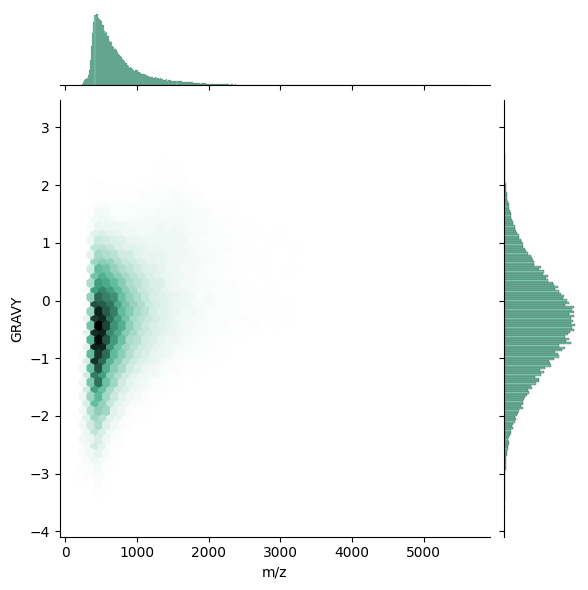

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
x = peptides_df['m/z']
y = peptides_df['GRAVY']


plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")


plt.show()

<Figure size 500x400 with 0 Axes>

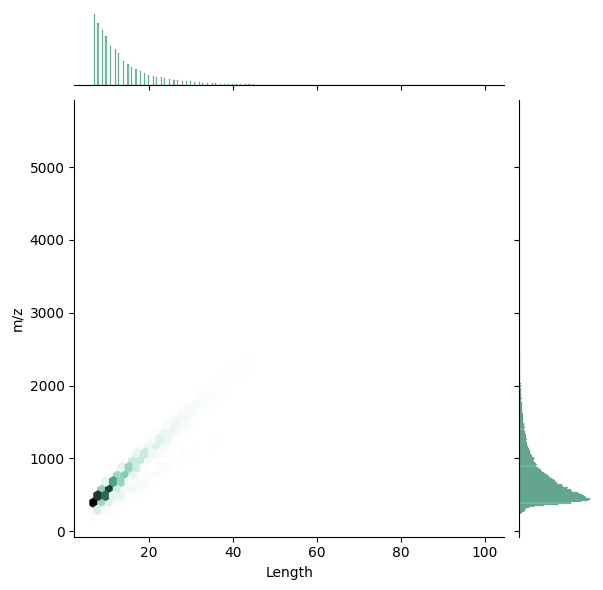

In [51]:
x = peptides_df['Length']
y = peptides_df['m/z']

plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")

plt.show()

In [52]:
peptide_counts = peptides_df.groupby('gene').size()
print(peptide_counts)



gene
1433B     3
1433E     3
1433F     3
1433G     3
1433S     4
         ..
ZY11A    18
ZY11B    14
ZYX      18
ZZEF1    41
ZZZ3     17
Length: 19714, dtype: int64


In [53]:
test_peptide="kkkkkkkkQSwwwwwwww"


In [54]:
silico.rules['q_sag'] = 'Q(?=[SAG])'

In [55]:
peptide_properties_df = silico.generate_samples(proteome_df, target="Peptide", identifier="Gene", enzyme="q_sag")


Processing your order with q_sag-cut proteins.
Generated 34082 peptides matching criteria.


In [56]:
peptides_df = pd.DataFrame(peptide_properties_df)
peptides_df

,gene,peptide,Length,aa_comp,z,Mass,GRAVY,m/z
0,HV692,SGAEVKKPGATVKISCKVSGYTFTDYYMHWVQQ,33,"{'S': 3, 'G': 3, 'A': 2, 'E': 1, 'M': 1, 'I': ...",2,3690.785053,-0.387879,1845.392527
1,A0A6Q8PGS0,MKAENRCRRRPPPALNAMSLGPRRARSAPTAVAAEAPVDAAELPQR...,86,"{'S': 3, 'G': 5, 'A': 15, 'E': 4, 'Q': 8, 'C':...",14,9630.202673,-0.880233,687.871620
2,DHR12,MSLYRSVVWFAKGLREYTKSGYESACKDFVPHDLEVQIPGRVFLVT...,74,"{'S': 5, 'D': 3, 'G': 9, 'Q': 2, 'C': 2, 'W': ...",3,8090.213836,-0.102703,2696.737945
3,MA13P,GTLEKVSASGTPGTPQSSQRVCSPCTTIKATPWNQ,35,"{'S': 5, 'G': 3, 'A': 2, 'E': 1, 'Q': 3, 'I': ...",2,3600.718850,-0.605714,1800.359425
4,MA13P,SSQRVCSPCTTIKATPWNQ,19,"{'S': 3, 'A': 1, 'Q': 2, 'I': 1, 'C': 2, 'N': ...",2,2089.956111,-0.631579,1044.978055
...,...,...,...,...,...,...,...,...
34077,RPKL1,AHTQLQLPEWLSRPAASLLTELLQFEPTRRLGMGEGGVSKLKSHPF...,57,"{'S': 6, 'G': 5, 'A': 3, 'E': 4, 'M': 1, 'Q': ...",2,6354.389217,-0.189474,3177.194608
34078,ZHX2,SVPPTITVLPAQLAPTKVTQPILQTALPCQILGQTSLVLTQVTSGS...,74,"{'S': 6, 'G': 4, 'A': 5, 'I': 4, 'Q': 8, 'C': ...",3,7556.018845,0.366216,2518.672948
34079,ZHX2,AAPEPKRPHIAQVPEPPPKVANPPLTPASDRKKTKEQIAHLKASFLQ,47,"{'S': 2, 'A': 7, 'E': 3, 'I': 2, 'Q': 3, 'N': ...",4,5109.835621,-0.885106,1277.458905
34080,ZHX2,SQFPDDAEVYRLIEVTGLARSEIKKWFSDHRYRCQRGIVHITSESL...,78,"{'T': 4, 'S': 6, 'G': 3, 'K': 6, 'A': 8, 'E': ...",3,9071.633505,-0.788462,3023.877835


In [57]:
peptide_counts = peptides_df.groupby('gene').size()
print(peptide_counts)


gene
1A1L2    2
2A5A     2
2A5B     1
2A5D     4
2A5E     2
        ..
ZXDB     2
ZXDC     6
ZY11A    1
ZZEF1    5
ZZZ3     3
Length: 11953, dtype: int64


<Figure size 500x400 with 0 Axes>

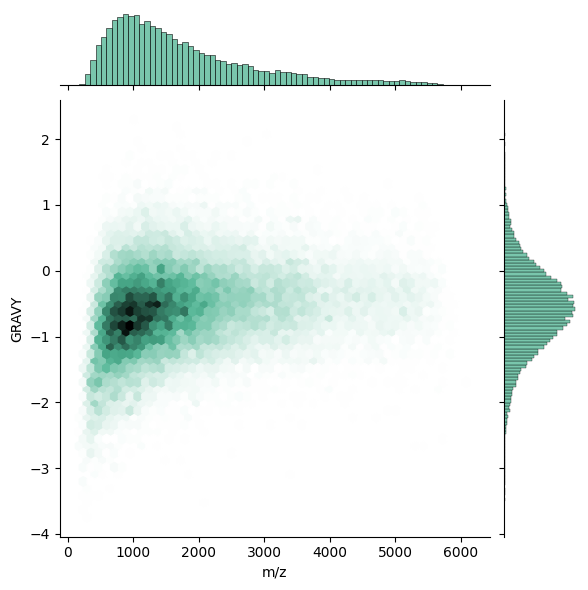

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
x = peptides_df['m/z']
y = peptides_df['GRAVY']

# Plot the joint distribution using hexagonal bins
plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")

# Show the plot
plt.show()

<Figure size 500x400 with 0 Axes>

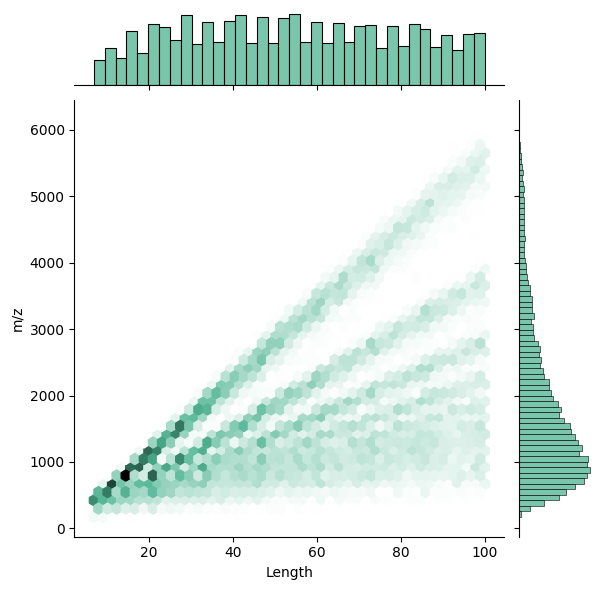

In [59]:
x = peptides_df['Length']
y = peptides_df['m/z']

# Plot the joint distribution using hexagonal bins
plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")

# Show the plot
plt.show()

In [60]:
# x="m/z"
# y="GRAVY"
# g = sns.jointplot(
#     data=peptides_df,
#     x="m/z",
#     y="GRAVY",
#     kind="kde",
# )

# # Set font size for various elements
# g.set_axis_labels("m/z", "Length", fontsize=14)  # Set axis label font size
# g.ax_joint.tick_params(axis='both', which='major', labelsize=14)  # Set tick label font size

# # Show the plot
# plt.show()


### Use this to compare two enzymes, need to merge df first. 